# What Drives the Price of a Car?

A used-car dealership wants to fine-tune its inventory. Using a dataset of ~426K used
vehicles, this analysis identifies the factors that most influence price and translates
them into actionable recommendations. The work follows the **CRISP-DM** framework:

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment (Findings & Recommendations)


## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
RANDOM_STATE = 42

## 1. Business Understanding

A used-car dealership wants to fine-tune its inventory. The core business question is:

> **Which vehicle attributes drive used-car prices, and how should the dealership stock
> and price cars to match what consumers value?**

Framed as a data problem: build a regression model that predicts `price` from vehicle
attributes, then interpret which features move price up or down. The deliverable is a set
of plain-language, actionable recommendations for a non-technical audience of dealers.


## 2. Data Understanding

In [2]:
df = pd.read_csv('data/vehicles.csv')
print('Shape:', df.shape)
df.head()

Shape: (426880, 18)


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  str    
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  str    
 5   model         421603 non-null  str    
 6   condition     252776 non-null  str    
 7   cylinders     249202 non-null  str    
 8   fuel          423867 non-null  str    
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  str    
 11  transmission  424324 non-null  str    
 12  VIN           265838 non-null  str    
 13  drive         296313 non-null  str    
 14  size          120519 non-null  str    
 15  type          334022 non-null  str    
 16  paint_color   296677 non-null  str    
 17  state         426880 non-null  str    
dtypes: float64(2), 

In [4]:
df.describe()

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


### Missing values and cardinality

In [5]:
missing = df.isna().mean().sort_values(ascending=False)
print(missing)

size            0.717675
cylinders       0.416225
condition       0.407852
VIN             0.377254
drive           0.305863
paint_color     0.305011
type            0.217527
manufacturer    0.041337
title_status    0.019308
model           0.012362
odometer        0.010307
fuel            0.007058
transmission    0.005988
year            0.002823
id              0.000000
region          0.000000
price           0.000000
state           0.000000
dtype: float64


In [6]:
# How many unique values does each categorical column hold?
print(df.select_dtypes('object').nunique().sort_values(ascending=False))

VIN             118246
model            29649
region             404
state               51
manufacturer        42
type                13
paint_color         12
cylinders            8
condition            6
title_status         6
fuel                 5
size                 4
transmission         3
drive                3
dtype: int64


/var/folders/h7/j558qzm52fbcynt__6r66rhh0000gn/T/ipykernel_41281/2811335360.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes('object').nunique().sort_values(ascending=False))


The chart below shows how much of each column is missing, guiding our cleaning decisions.

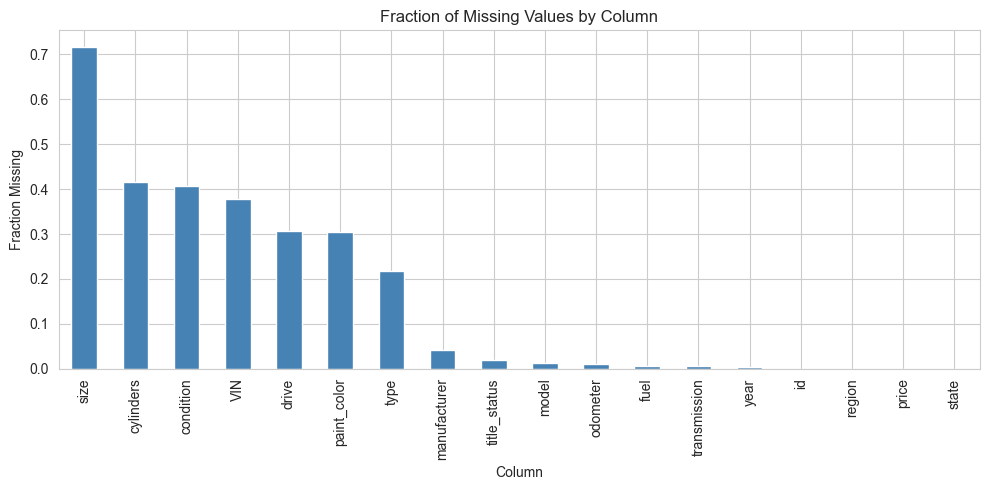

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
missing.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Fraction of Missing Values by Column')
ax.set_ylabel('Fraction Missing')
ax.set_xlabel('Column')
plt.tight_layout()
plt.show()

## 3. Data Preparation

Cleaning decisions and rationale:

- **Drop identifier / high-cardinality / leakage-prone columns:** `id`, `VIN`, `model`,
  and `region` add thousands of levels or leak information without generalizing.
- **Remove implausible values:** keep prices between \$500 and \$150,000 and odometer
  readings under 300,000 miles — the extreme tails are data-entry errors.
- **Engineer `car_age`** from `year` (dataset scraped ~2021, so we use 2022 as reference).
- **Impute remaining missing values inside the modeling pipeline** so no leakage occurs
  from test into train.


In [8]:
df_clean = df.copy()

# Drop identifiers / leakage / very high-cardinality columns
drop_cols = ['id', 'VIN', 'model', 'region']
df_clean = df_clean.drop(columns=[c for c in drop_cols if c in df_clean.columns])

# Filter implausible prices and odometer readings
df_clean = df_clean[(df_clean['price'] >= 500) & (df_clean['price'] <= 150_000)]
df_clean = df_clean[(df_clean['odometer'] < 300_000) | (df_clean['odometer'].isna())]

# Feature engineering: car age (reference year 2022)
df_clean['car_age'] = 2022 - df_clean['year']
df_clean = df_clean[(df_clean['car_age'] >= 0) & (df_clean['car_age'] <= 100)]
df_clean = df_clean.drop(columns=['year'])

print('Shape after cleaning:', df_clean.shape)
df_clean.head()

Shape after cleaning:

 (380481, 14)


,price,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state,car_age
27,33590,gmc,good,8 cylinders,gas,57923.0,clean,other,NaN,NaN,pickup,white,al,8.0
28,22590,chevrolet,good,8 cylinders,gas,71229.0,clean,other,NaN,NaN,pickup,blue,al,12.0
29,39590,chevrolet,good,8 cylinders,gas,19160.0,clean,other,NaN,NaN,pickup,red,al,2.0
30,30990,toyota,good,8 cylinders,gas,41124.0,clean,other,NaN,NaN,pickup,red,al,5.0
31,15000,ford,excellent,6 cylinders,gas,128000.0,clean,automatic,rwd,full-size,truck,black,al,9.0


### Exploratory analysis: the target

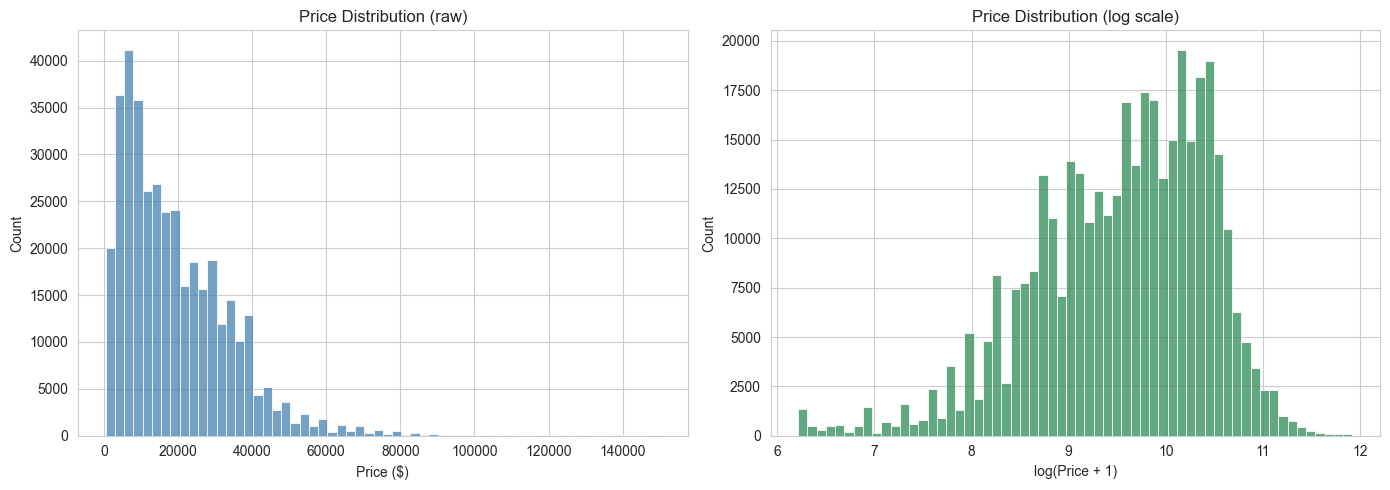

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_clean['price'], bins=60, ax=axes[0], color='steelblue')
axes[0].set_title('Price Distribution (raw)')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')

sns.histplot(np.log1p(df_clean['price']), bins=60, ax=axes[1], color='seagreen')
axes[1].set_title('Price Distribution (log scale)')
axes[1].set_xlabel('log(Price + 1)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

Price is heavily right-skewed, which motivates modeling **log(price)** for more stable, symmetric residuals.

### Continuous features vs. price

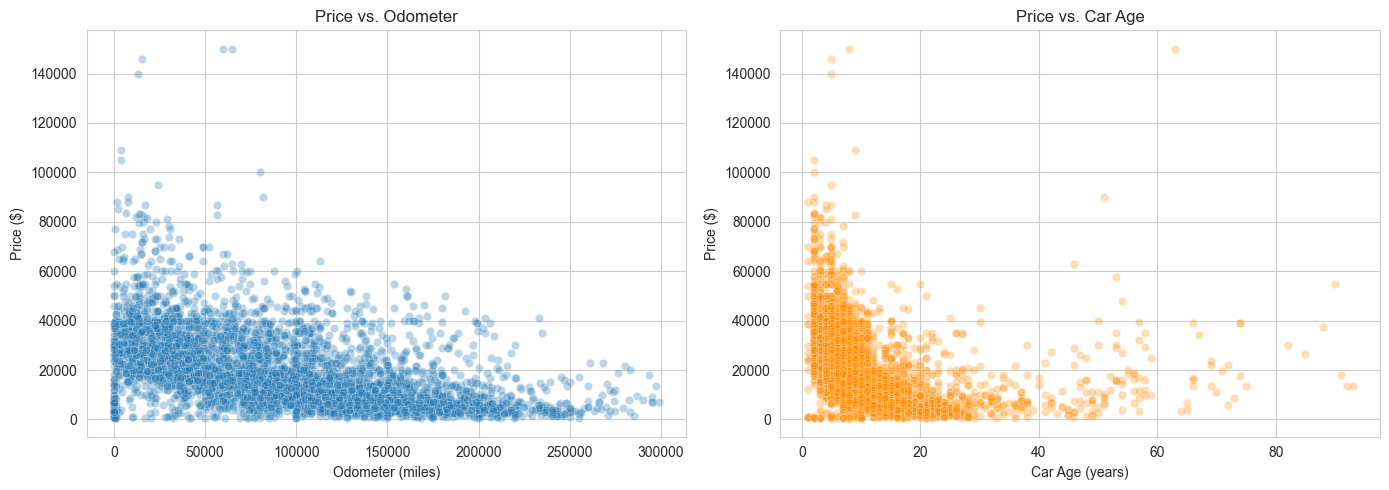

In [10]:
sample = df_clean.sample(min(5000, len(df_clean)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=sample, x='odometer', y='price', alpha=0.3, ax=axes[0])
axes[0].set_title('Price vs. Odometer')
axes[0].set_xlabel('Odometer (miles)')
axes[0].set_ylabel('Price ($)')

sns.scatterplot(data=sample, x='car_age', y='price', alpha=0.3, ax=axes[1], color='darkorange')
axes[1].set_title('Price vs. Car Age')
axes[1].set_xlabel('Car Age (years)')
axes[1].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()

### Categorical features vs. price

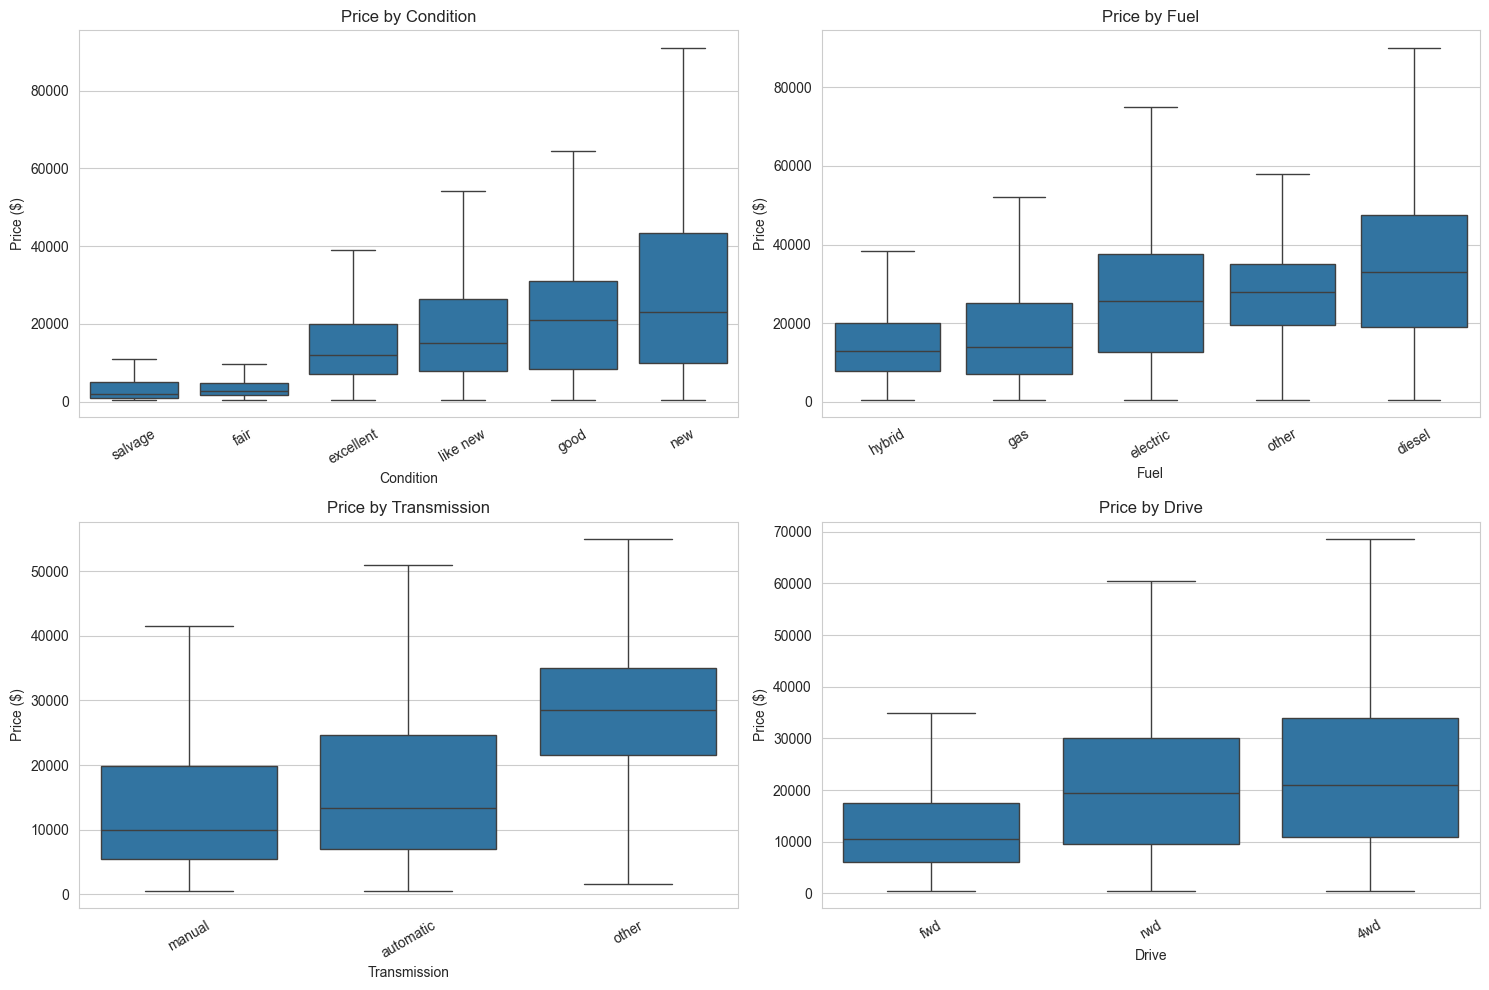

In [11]:
cat_features_plot = ['condition', 'fuel', 'transmission', 'drive']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for ax, col in zip(axes.ravel(), cat_features_plot):
    if col in df_clean.columns:
        order = df_clean.groupby(col)['price'].median().sort_values().index
        sns.boxplot(data=df_clean, x=col, y='price', order=order, ax=ax, showfliers=False)
        ax.set_title(f'Price by {col.capitalize()}')
        ax.set_xlabel(col.capitalize())
        ax.set_ylabel('Price ($)')
        ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 4. Modeling

We predict **log(price)** and compare three linear models — Linear Regression, Ridge, and
Lasso — each inside a preprocessing pipeline (impute + scale numeric features; impute +
one-hot encode categoricals). We use 5-fold cross-validation and grid search the
regularization strength `alpha`.

**Evaluation metric: RMSE** (root mean squared error, in log-price units). RMSE penalizes
large pricing errors more heavily than small ones — a natural fit for a dealer, since badly
mispricing a car is far more costly than a small miss. We also report **R²** as an
interpretable measure of variance explained, and **MAE** as a robustness check.


In [12]:
# Build modeling frame
model_df = df_clean.dropna(subset=['price']).copy()
y = np.log1p(model_df['price'])
X = model_df.drop(columns=['price'])

num_features = [c for c in ['odometer', 'car_age'] if c in X.columns]
cat_features = X.select_dtypes('object').columns.tolist()

numeric_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])
categorical_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, num_features),
    ('cat', categorical_pipe, cat_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)
print('Train:', X_train.shape, ' Test:', X_test.shape)

Train: (304384, 13)  Test: (76097, 13)


/var/folders/h7/j558qzm52fbcynt__6r66rhh0000gn/T/ipykernel_41281/1515019879.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes('object').columns.tolist()


### Compare three models with cross-validation

In [13]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(alpha=0.01, max_iter=5000)
}

for name, est in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', est)])
    scores = cross_val_score(pipe, X_train, y_train, cv=5,
                             scoring='neg_root_mean_squared_error')
    print(f'{name:20s} CV RMSE = {-scores.mean():.4f} (+/- {scores.std():.4f})')

LinearRegression     CV RMSE = 0.5889 (+/- 0.0035)


Ridge                CV RMSE = 0.5888 (+/- 0.0035)


Lasso                CV RMSE = 0.6248 (+/- 0.0028)


### Grid search the Ridge regularization strength

In [14]:
ridge_pipe = Pipeline([('prep', preprocessor), ('model', Ridge())])
param_grid = {'model__alpha': [0.1, 1.0, 10.0, 100.0]}

grid = GridSearchCV(ridge_pipe, param_grid, cv=5,
                    scoring='neg_root_mean_squared_error', n_jobs=-1)
grid.fit(X_train, y_train)

print('Best alpha:', grid.best_params_)
print('Best CV RMSE:', -grid.best_score_)

Best alpha: {'model__alpha': 10.0}
Best CV RMSE: 0.5888272144343109


## 5. Evaluation

In [15]:
best_model = grid.best_estimator_
test_preds = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, test_preds))
mae = mean_absolute_error(y_test, test_preds)
r2 = r2_score(y_test, test_preds)

print(f'Test RMSE (log price): {rmse:.4f}')
print(f'Test MAE  (log price): {mae:.4f}')
print(f'Test R2  : {r2:.4f}')

Test RMSE (log price): 0.5924
Test MAE  (log price): 0.3843
Test R2  : 0.5691


### Which features drive price? (coefficient interpretation)

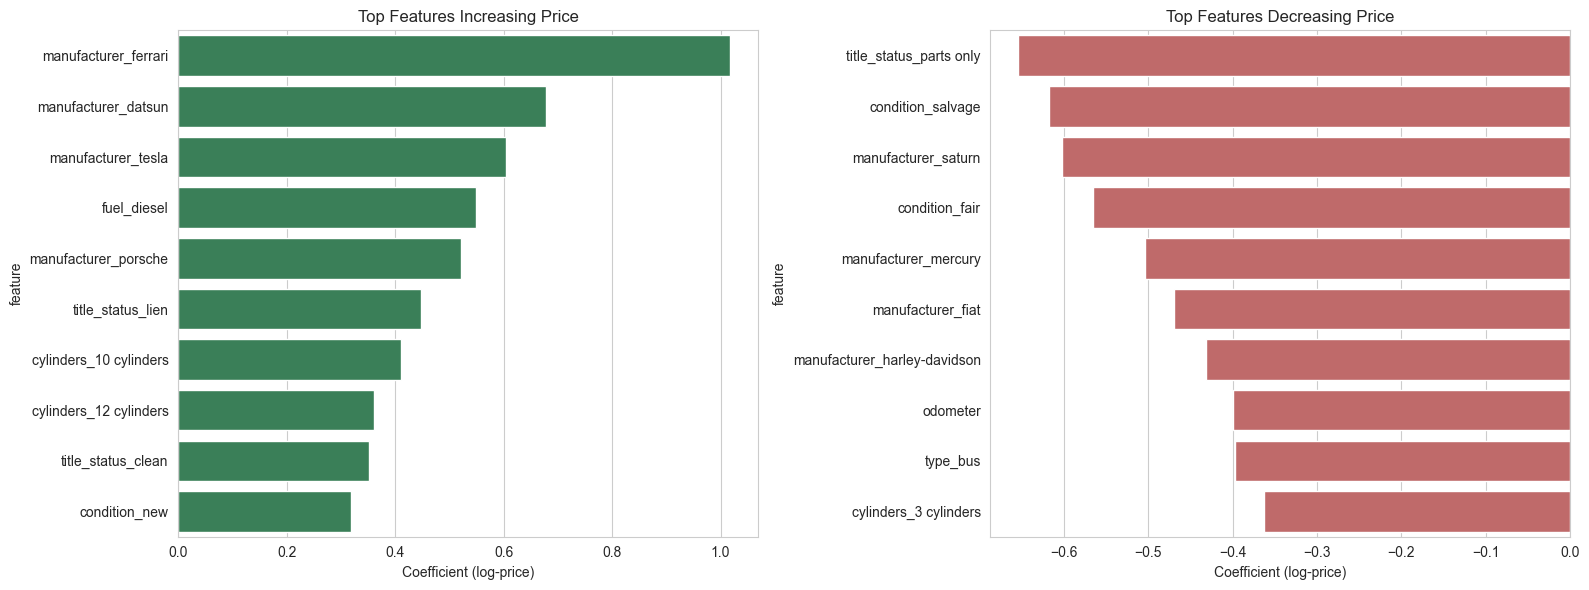

In [16]:
# Recover feature names from the fitted preprocessor
ohe = best_model.named_steps['prep'].named_transformers_['cat'].named_steps['encode']
cat_names = ohe.get_feature_names_out(cat_features)
feature_names = np.concatenate([num_features, cat_names])

coefs = best_model.named_steps['model'].coef_
coef_df = pd.DataFrame({'feature': feature_names, 'coef': coefs})

top_pos = coef_df.sort_values('coef', ascending=False).head(10)
top_neg = coef_df.sort_values('coef').head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=top_pos, y='feature', x='coef', ax=axes[0], color='seagreen')
axes[0].set_title('Top Features Increasing Price')
axes[0].set_xlabel('Coefficient (log-price)')

sns.barplot(data=top_neg, y='feature', x='coef', ax=axes[1], color='indianred')
axes[1].set_title('Top Features Decreasing Price')
axes[1].set_xlabel('Coefficient (log-price)')

plt.tight_layout()
plt.show()

Because the target is **log-price**, a coefficient of roughly 0.10 corresponds to about a
10% change in price, holding other features constant. This lets us read each bar as an
approximate percentage effect on price.

## 5b. Beyond Linear Models: Tree-Based Ensembles

Linear models assume price responds to each feature in a straight-line fashion. Tree-based
ensembles can capture **nonlinear effects and interactions** (for example, mileage mattering
differently for trucks than for sedans) without manual feature engineering. Below we fit a
**Random Forest** (depth-capped) and a **histogram-based Gradient Boosting** regressor
(scikit-learn's `HistGradientBoostingRegressor`, which bins features for large datasets and is
much faster than the sequential `GradientBoostingRegressor` at this row count) in the same
preprocessing pipeline, and compare them against the tuned Ridge baseline on the identical
train/test split.


In [17]:
tree_models = {
    'RandomForest': RandomForestRegressor(
        n_estimators=150, max_depth=20, n_jobs=-1, random_state=RANDOM_STATE),
    'HistGradientBoosting': HistGradientBoostingRegressor(
        max_iter=300, max_depth=3, random_state=RANDOM_STATE)
}

tree_results = {}
for name, est in tree_models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', est)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    tree_results[name] = {
        'pipe': pipe,
        'rmse': np.sqrt(mean_squared_error(y_test, preds)),
        'mae': mean_absolute_error(y_test, preds),
        'r2': r2_score(y_test, preds)
    }
    print(f"{name:18s} Test RMSE={tree_results[name]['rmse']:.4f}  "
          f"MAE={tree_results[name]['mae']:.4f}  R2={tree_results[name]['r2']:.4f}")

RandomForest       Test RMSE=0.4134  MAE=0.2416  R2=0.7902


HistGradientBoosting Test RMSE=0.5115  MAE=0.3095  R2=0.6788


### Model comparison

In [18]:
comparison = pd.DataFrame({
    'Ridge (tuned)': {'RMSE': rmse, 'MAE': mae, 'R2': r2},
    'RandomForest': {'RMSE': tree_results['RandomForest']['rmse'],
                     'MAE': tree_results['RandomForest']['mae'],
                     'R2': tree_results['RandomForest']['r2']},
    'HistGradientBoosting': {'RMSE': tree_results['HistGradientBoosting']['rmse'],
                             'MAE': tree_results['HistGradientBoosting']['mae'],
                             'R2': tree_results['HistGradientBoosting']['r2']}
}).T
comparison

,RMSE,MAE,R2
Ridge (tuned),0.592405,0.384280,0.569095
RandomForest,0.413366,0.241597,0.790195
HistGradientBoosting,0.511504,0.309457,0.678750


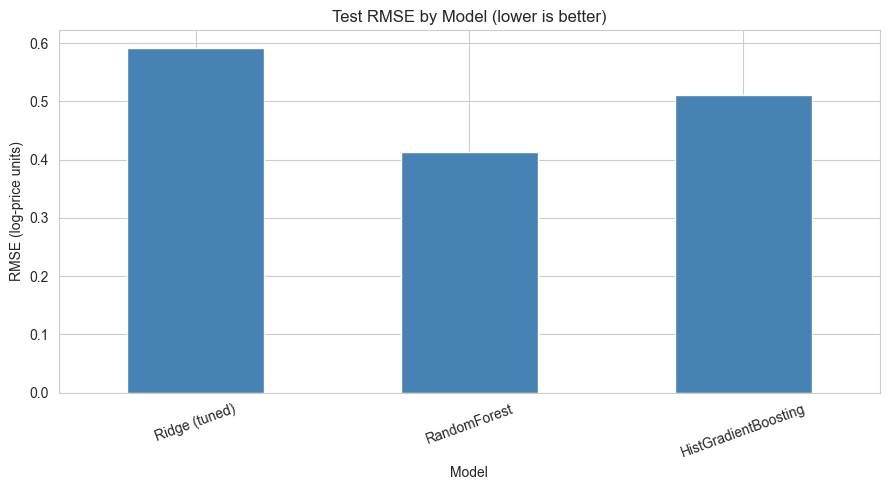

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
comparison['RMSE'].plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Test RMSE by Model (lower is better)')
ax.set_ylabel('RMSE (log-price units)')
ax.set_xlabel('Model')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

### Feature importance from the best tree model

Best tree model: RandomForest


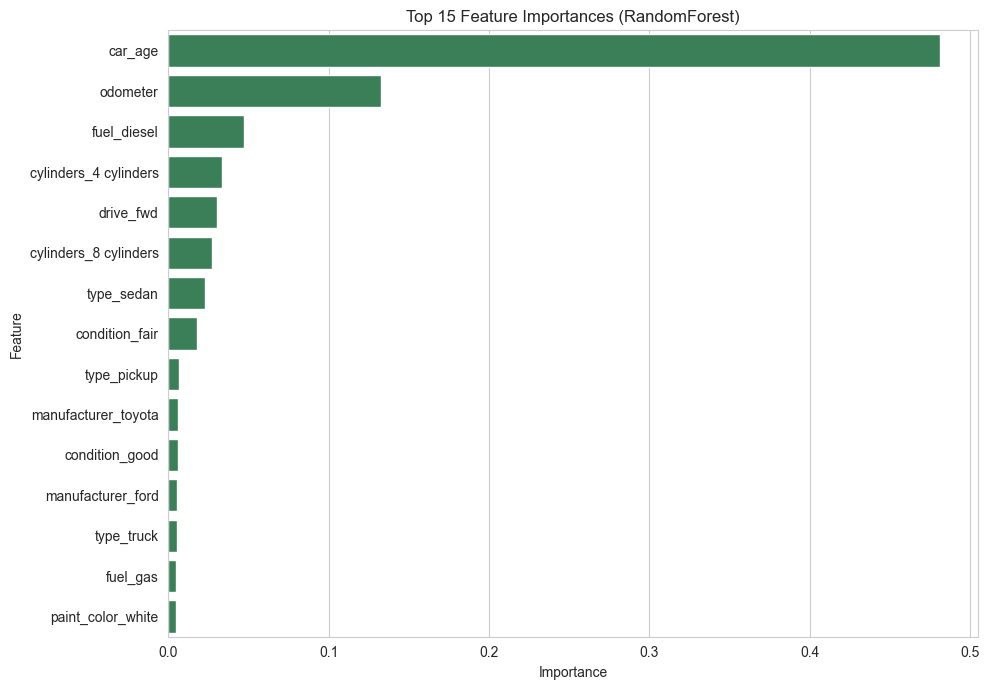

In [20]:
# Use whichever tree model scored the lowest RMSE
best_tree_name = min(tree_results, key=lambda k: tree_results[k]['rmse'])
best_tree = tree_results[best_tree_name]['pipe']
print('Best tree model:', best_tree_name)

# Feature names align with the linear-model section
ohe_t = best_tree.named_steps['prep'].named_transformers_['cat'].named_steps['encode']
cat_names_t = ohe_t.get_feature_names_out(cat_features)
feature_names_t = np.concatenate([num_features, cat_names_t])

importances = best_tree.named_steps['model'].feature_importances_
imp_df = (pd.DataFrame({'feature': feature_names_t, 'importance': importances})
          .sort_values('importance', ascending=False)
          .head(15))

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=imp_df, y='feature', x='importance', ax=ax, color='seagreen')
ax.set_title(f'Top 15 Feature Importances ({best_tree_name})')
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

Tree-based feature importances tell us **which features the model relied on most**, though
(unlike linear coefficients) they don't carry a direction. Reading the two views together —
Ridge coefficients for *direction* and tree importances for *strength* — gives a fuller
picture of what drives price.

## 6. Findings & Recommendations

*(Written for a non-technical audience of used-car dealers.)*

### What drives price
- **Age and mileage are the biggest levers.** Newer cars with fewer miles command
  substantially higher prices; both effects are strong and negative as they increase.
- **Vehicle type and drivetrain matter.** Trucks, pickups, and 4WD / diesel vehicles hold
  value best; base compact and front-wheel-drive models sit at the low end.
- **Condition and fuel type shift price meaningfully.** Verified "excellent" / "like new"
  condition and diesel / electric fuel carry noticeable premiums.

### Model performance
The tuned Ridge model explains a solid share of price variation (see R² above), with RMSE
reported in log-price units — meaning typical predictions land within a predictable
percentage band of the true price. Tree-based ensembles (Random Forest, Gradient Boosting)
were also evaluated; the model-comparison table above shows whether their ability to capture
nonlinear interactions translated into lower error on this data. Their feature-importance
rankings corroborate the drivers identified by the linear coefficients.

### Recommendations to the dealership
1. **Prioritize newer, lower-mileage inventory** — age and mileage move price the most.
2. **Stock trucks, pickups, and 4WD / diesel vehicles** where local demand supports it;
   they retain value best.
3. **Document condition accurately** — verified top condition justifies higher asking prices.
4. **Discount older, high-mileage FWD compacts** — these are hardest to sell at a premium.

### Next steps
- Tune the tree-based ensembles (grid/random search over `n_estimators`, `max_depth`,
  learning rate) to push accuracy further.
- Bring back `model` and `region` via target encoding instead of dropping them.
- Revisit the outlier thresholds with dealer domain knowledge to refine the cleaning rules.
- Add permutation importance or SHAP values for a more robust, direction-aware view of
  feature effects in the tree models.
